# OSM roads — Viladecans

Loads the enriched strategic-noise-map segments (real modeled dB values per street
axis, day/evening/night), downloads the OSM drive network for Viladecans, assigns
each OSM street segment the noise values of the nearest noise-map segment (via the
segment midpoint), classifies the dB values into the 5 noise classes used by the ML
pipeline, computes distance-to-road-category features and exports
`../layers/VIL_noise_streets.gpkg` and `data/osm_roads_noise_class.csv`.

In [1]:
import os
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse the strategic noise map segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
noise_lines = gpd.read_file(os.path.join(_layers_dir, 'viladecans_noise_enriched.geojson'))
noise_lines = noise_lines.to_crs('EPSG:25831')
print('CRS:', noise_lines.crs)
print('Shape:', noise_lines.shape)
noise_lines[['db_day', 'db_evening', 'db_night']].describe()

CRS: EPSG:25831
Shape: (1190, 59)


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,db_day,db_evening,db_night
count,1190.000000,1190.000000,1190.000000
mean,57.987395,53.342017,48.137815
std,5.913507,7.002931,6.894580
min,42.000000,36.000000,31.000000
25%,55.000000,49.000000,44.000000
50%,59.000000,53.000000,48.000000
75%,61.000000,59.000000,53.000000
max,74.000000,72.000000,65.000000


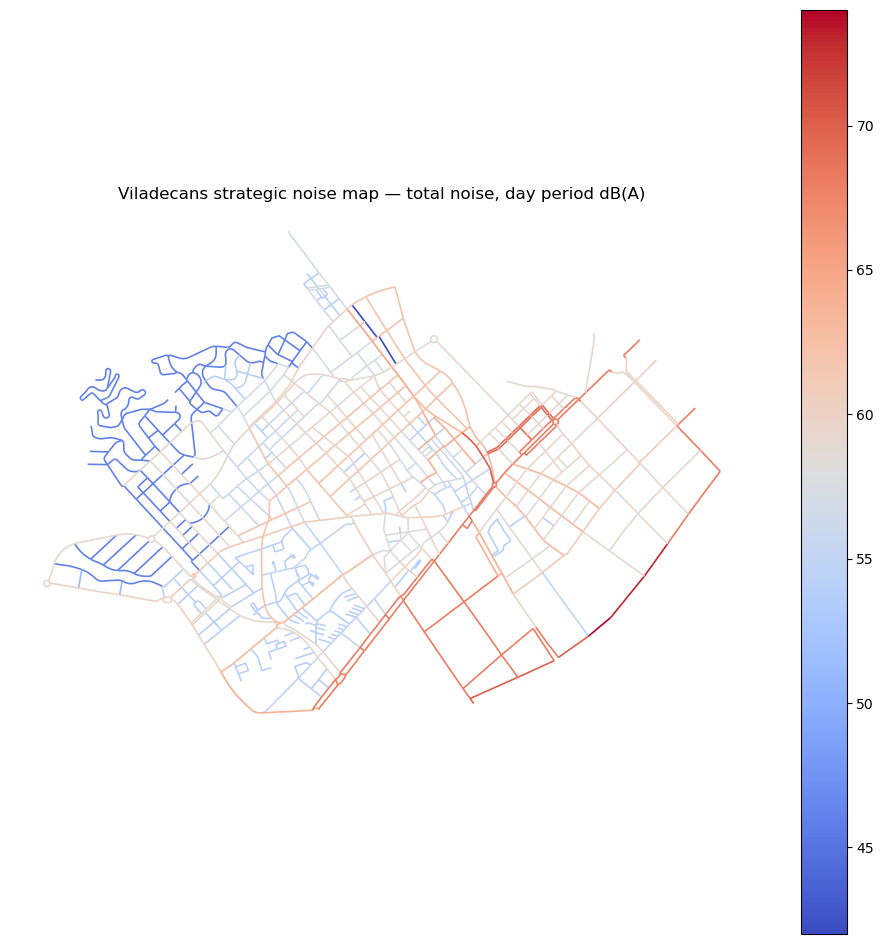

In [3]:
ax = noise_lines.plot(column='db_day', cmap='coolwarm', linewidth=1.2,
                      legend=True, figsize=(12, 12))
ax.set_title('Viladecans strategic noise map — total noise, day period dB(A)')
ax.set_axis_off()
plt.show()

## Roads - OSM

Loading cached graph from data\viladecans.graphml


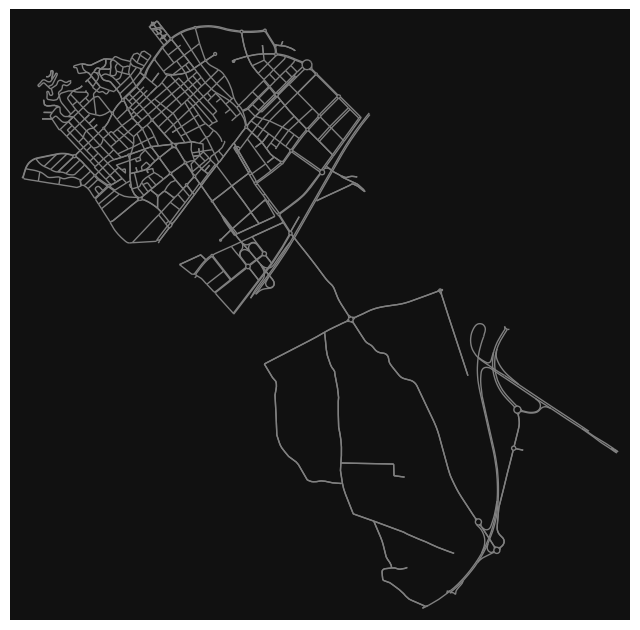

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
GRAPHML_PATH = os.path.join('data', 'viladecans.graphml')
os.makedirs('data', exist_ok=True)

if os.path.exists(GRAPHML_PATH):
    print('Loading cached graph from', GRAPHML_PATH)
    G = ox.load_graphml(GRAPHML_PATH)
else:
    print('Downloading Viladecans OSM graph (drive network) ...')
    G = ox.graph_from_place('Viladecans, Spain', network_type='drive')
    ox.save_graphml(G, GRAPHML_PATH)

ox.plot_graph(G, edge_color='gray', node_size=0)

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as the noise-map segments (EPSG:25831 — ETRS89 / UTM 31N)
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_lines.crs)
print('Roads:', len(roads), 'CRS:', roads.crs)

Roads: 1738 CRS: EPSG:25831


## Check features completeness

In [6]:
for col in ['width', 'maxspeed', 'lanes', 'oneway']:
    if col in roads.columns:
        print(f'Checking {col}..')
        print(roads[col].value_counts(dropna=False).head(20))
    else:
        print(f'{col}: column not present')

Checking width..
width
NaN    1704
12       20
4.2       4
10        4
5.6       2
3         2
5         1
4.3       1
Name: count, dtype: int64
Checking maxspeed..
maxspeed
30            1210
40             236
50              93
10              74
NaN             42
20              35
100              8
[30, 10]         7
[10, 20]         6
70               4
120              3
60               3
80               3
[50, 60]         2
[100, 120]       2
90               2
[50, 20]         2
[50, 30]         2
[40, 60]         1
[80, 120]        1
Name: count, dtype: int64
Checking lanes..
lanes
1         1007
2          620
NaN         38
4           38
3           20
[1, 2]       6
[2, 3]       5
[3, 4]       3
[5, 4]       1
Name: count, dtype: int64
Checking oneway..
oneway
True     1226
False     512
Name: count, dtype: int64


## Check if road is tunnel

In [7]:
# OSM 'tunnel' values can be strings or lists — mark as tunnel if any value is 'yes'
if 'tunnel' in roads.columns:
    roads['is_tunnel'] = roads['tunnel'].apply(
        lambda v: 1 if v == 'yes' or (isinstance(v, list) and 'yes' in v) else 0
    )
else:
    roads['is_tunnel'] = 0

print(roads['is_tunnel'].value_counts())

is_tunnel
0    1735
1       3
Name: count, dtype: int64


## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 1738, Filtered: 1613


## Plot road categories distribution

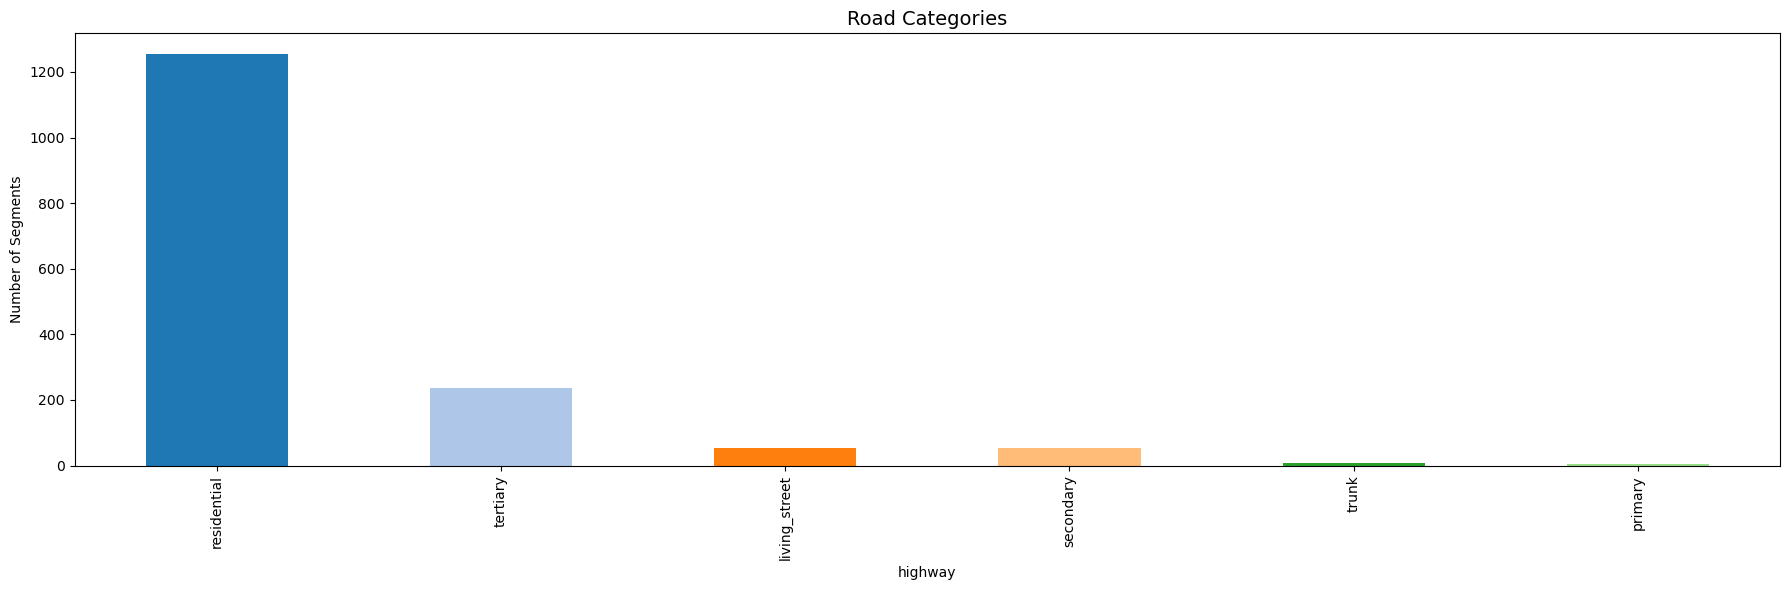

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

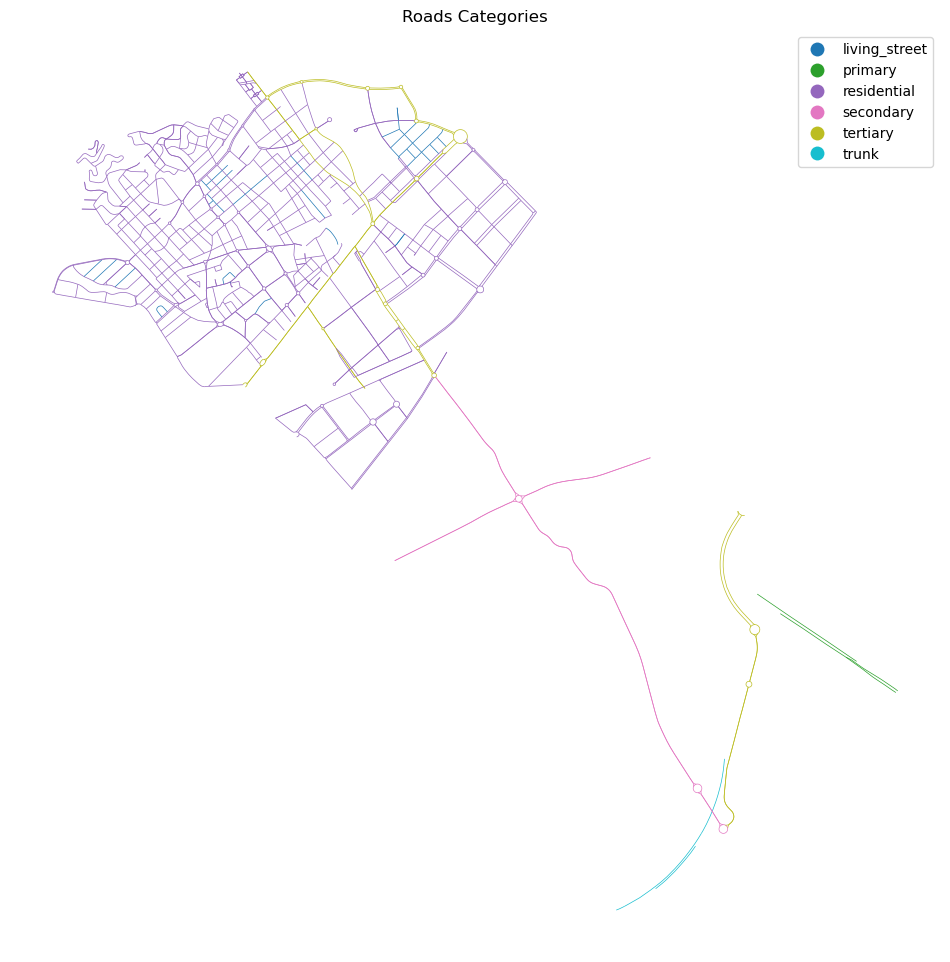

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign noise values to each street segment

Each OSM segment inherits `db_day`, `db_evening` and `db_night` from the nearest
noise-map street axis (matched via the OSM segment midpoint with `sjoin_nearest`).
The match distance is recorded — OSM centerlines and the municipal street axes
should nearly coincide, so most distances are expected below ~30 m.

In [11]:
# Midpoint -> nearest noise-map segment join
noise_roads = roads_filtered.reset_index(drop=True).copy()
midpoints = noise_roads[['segment_id']].copy()
midpoints = gpd.GeoDataFrame(midpoints,
                             geometry=noise_roads.geometry.interpolate(0.5, normalized=True),
                             crs=noise_roads.crs)

noise_cols = ['db_day', 'db_evening', 'db_night']
joined = gpd.sjoin_nearest(midpoints, noise_lines[noise_cols + ['geometry']],
                           how='left', distance_col='distance')
# Equidistant ties can match twice - keep the first match
joined = joined[~joined.index.duplicated(keep='first')]

for c in noise_cols:
    noise_roads[c] = joined[c]
noise_roads['distance'] = joined['distance']

noise_roads = noise_roads[noise_roads['db_day'].notna()].copy()
print(f'Segments with noise values: {len(noise_roads)} / {len(midpoints)}')
print('Match distance stats (m):')
print(noise_roads['distance'].describe())
print(f"Segments matched farther than 50 m: {(noise_roads['distance'] > 50).sum()}")
noise_roads[noise_cols + ['distance']].describe()

Segments with noise values: 1613 / 1613
Match distance stats (m):
count    1613.000000
mean      180.508316
std       693.259309
min         0.000599
25%         0.512897
50%         1.338611
75%         5.631793
max      4207.733267
Name: distance, dtype: float64
Segments matched farther than 50 m: 222


,db_day,db_evening,db_night,distance
count,1613.000000,1613.000000,1613.000000,1613.000000
mean,59.886547,55.707378,50.356479,180.508316
std,6.733413,7.805239,7.578212,693.259309
min,46.000000,40.000000,35.000000,0.000599
25%,56.000000,51.000000,46.000000,0.512897
50%,59.000000,56.000000,51.000000,1.338611
75%,63.000000,61.000000,55.000000,5.631793
max,74.000000,72.000000,65.000000,4207.733267


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [12]:
# Classify numeric noise dB into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(val):
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise(72.3))  # expected: 4

4


In [13]:
# The Viladecans strategic noise map provides all three periods directly:
# day (7-21h), evening (21-23h) and night (23-7h)
noise_roads['noise_day'] = noise_roads['db_day'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['db_evening'].apply(classify_noise)
noise_roads['noise_night'] = noise_roads['db_night'].apply(classify_noise)

noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,...,tunnel,segment_id,is_tunnel,db_day,db_evening,db_night,distance,noise_day,noise_evening,noise_night
0,"[19803872, 674379918]",residential,NaN,NaN,"[Camí de la Via, Passatge de les Feixes Roca]",False,NaN,True,308.730134,"LINESTRING (417459.73 4573025.45, 417476.559 4...",...,NaN,206378333_6315715548_0,0,68,65,61,381.651447,3,3,3
1,1186547995,trunk,3,100,Autovia de Castelldefels,True,C-31,False,228.543751,"LINESTRING (420311.04 4569795.488, 420365.614 ...",...,NaN,208568922_208568921_0,0,70,67,61,4113.683446,4,3,3
2,1188682904,trunk,2,100,Autovia de Castelldefels,True,C-31,False,188.820045,"LINESTRING (420171.05 4569668.905, 420184.271 ...",...,NaN,208568926_208568922_1,0,70,67,61,4185.927121,4,3,3
3,314132714,trunk,2,100,Autovia de Castelldefels,True,C-31,False,562.235744,"LINESTRING (420662.232 4570595.151, 420657.012...",...,NaN,208595138_208595144_0,0,70,67,61,3852.324193,4,3,3
4,"[23094061, 1392152182, 1392152183]",trunk,"[2, 3]",100,Autovia de Castelldefels,True,C-31,False,490.626414,"LINESTRING (420497.215 4570063.453, 420473.432...",...,NaN,208595144_2332249073_0,0,70,67,61,4114.349935,4,3,3


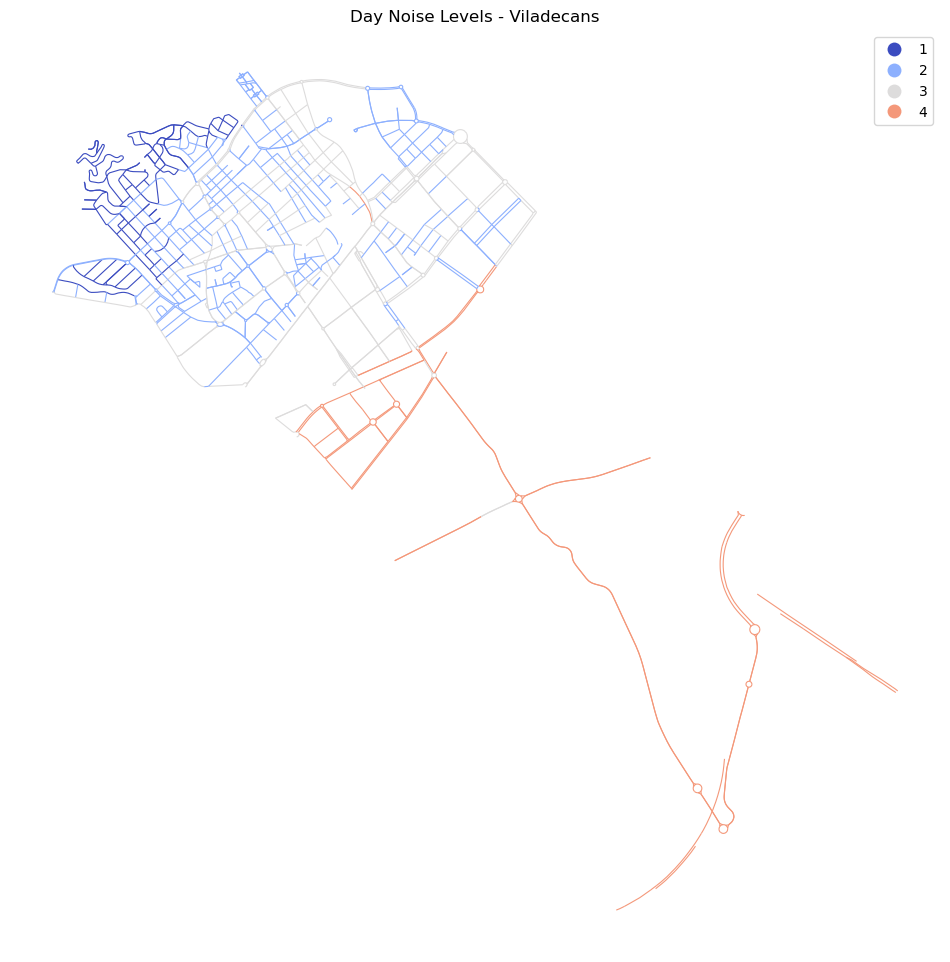

In [14]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Day Noise Levels - Viladecans')
ax.set_axis_off()

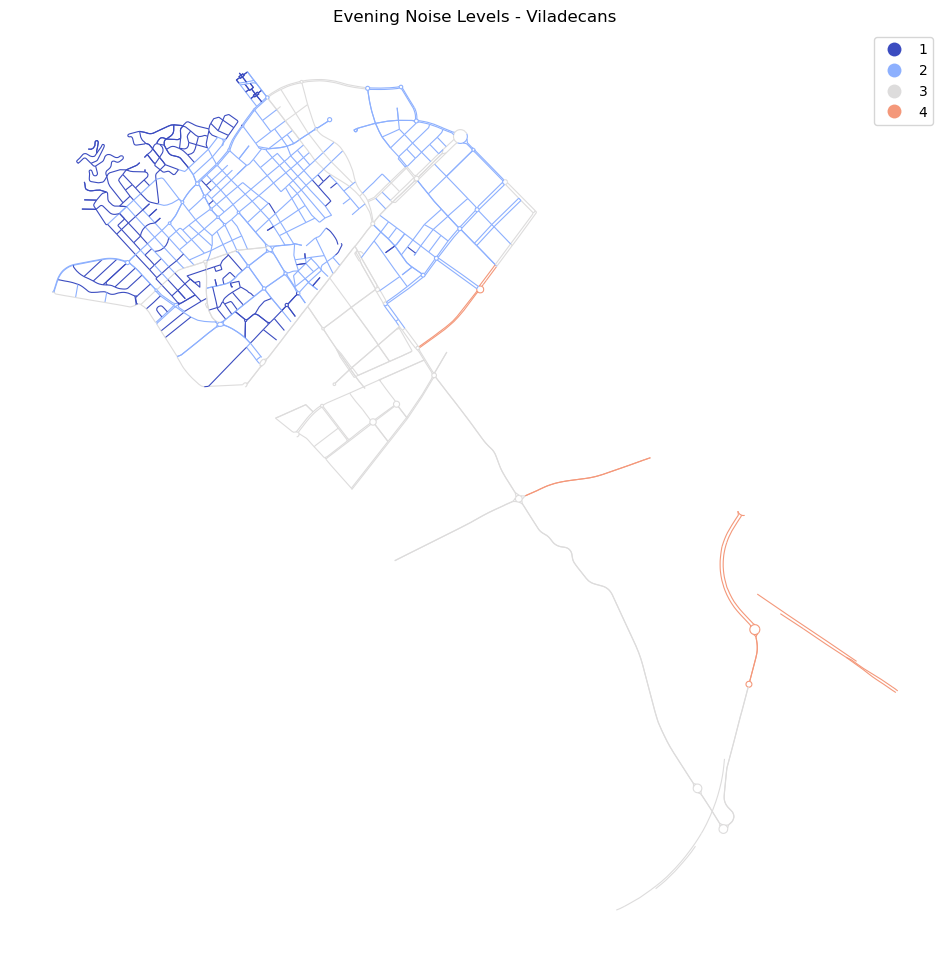

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Evening Noise Levels - Viladecans')
ax.set_axis_off()

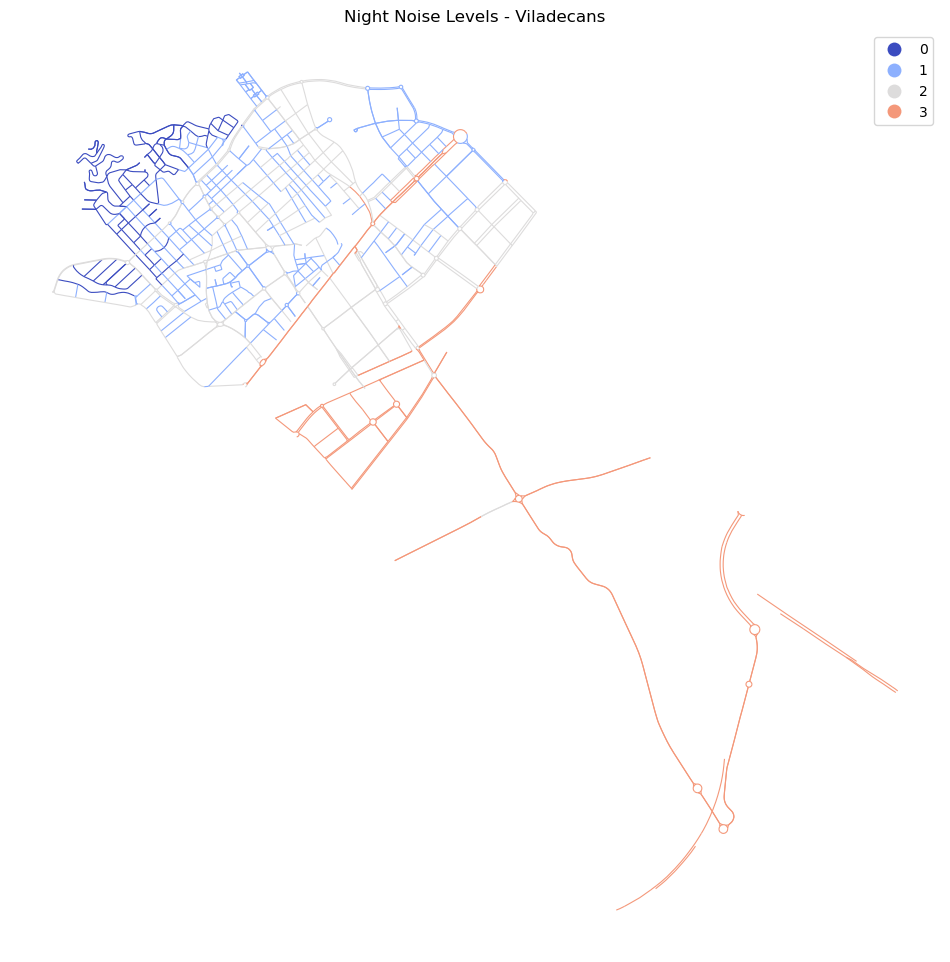

In [16]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Night Noise Levels - Viladecans')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      1255
tertiary          237
living_street      55
secondary          53
trunk               7
primary             6
Name: count, dtype: int64

In [18]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,...,is_tunnel,db_day,db_evening,db_night,distance,noise_day,noise_evening,noise_night,road_category,category_code
0,"[19803872, 674379918]",residential,NaN,NaN,"[Camí de la Via, Passatge de les Feixes Roca]",False,NaN,True,308.730134,"LINESTRING (417459.73 4573025.45, 417476.559 4...",...,0,68,65,61,381.651447,3,3,3,residential,5
1,1186547995,trunk,3,100,Autovia de Castelldefels,True,C-31,False,228.543751,"LINESTRING (420311.04 4569795.488, 420365.614 ...",...,0,70,67,61,4113.683446,4,3,3,trunk,1
2,1188682904,trunk,2,100,Autovia de Castelldefels,True,C-31,False,188.820045,"LINESTRING (420171.05 4569668.905, 420184.271 ...",...,0,70,67,61,4185.927121,4,3,3,trunk,1
3,314132714,trunk,2,100,Autovia de Castelldefels,True,C-31,False,562.235744,"LINESTRING (420662.232 4570595.151, 420657.012...",...,0,70,67,61,3852.324193,4,3,3,trunk,1
4,"[23094061, 1392152182, 1392152183]",trunk,"[2, 3]",100,Autovia de Castelldefels,True,C-31,False,490.626414,"LINESTRING (420497.215 4570063.453, 420473.432...",...,0,70,67,61,4114.349935,4,3,3,trunk,1


## Calculate distance to the closest road of each category

In [19]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,"[19803872, 674379918]",residential,NaN,NaN,"[Camí de la Via, Passatge de les Feixes Roca]",False,NaN,True,308.730134,"LINESTRING (417459.73 4573025.45, 417476.559 4...",...,3,3,residential,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769
1,1186547995,trunk,3,100,Autovia de Castelldefels,True,C-31,False,228.543751,"LINESTRING (420311.04 4569795.488, 420365.614 ...",...,3,3,trunk,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962
2,1188682904,trunk,2,100,Autovia de Castelldefels,True,C-31,False,188.820045,"LINESTRING (420171.05 4569668.905, 420184.271 ...",...,3,3,trunk,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827
3,314132714,trunk,2,100,Autovia de Castelldefels,True,C-31,False,562.235744,"LINESTRING (420662.232 4570595.151, 420657.012...",...,3,3,trunk,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919
4,"[23094061, 1392152182, 1392152183]",trunk,"[2, 3]",100,Autovia de Castelldefels,True,C-31,False,490.626414,"LINESTRING (420497.215 4570063.453, 420473.432...",...,3,3,trunk,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683


In [20]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,1613.000000,1613.000000,1613.000000,1613.000000,1613.000000,1613.000000
mean,4725.485128,4121.623825,1573.736595,404.914501,134.831557,436.928808
std,1106.175783,980.541693,677.713908,385.925402,606.990883,808.497873
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4396.836742,3758.062135,1142.627733,35.213617,0.000000,94.483906
50%,4918.734990,4305.998327,1643.292813,312.734609,0.000000,205.209253
75%,5429.504334,4824.039796,2102.445510,684.875956,0.000000,411.234728
max,6222.418896,5664.650873,2897.411424,1493.927288,3940.242912,4972.915179


## Calculate distance to major road

In [21]:
# Filter target roads
target_categories = ['trunk', 'primary', 'secondary' ]
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,"[19803872, 674379918]",residential,NaN,NaN,"[Camí de la Via, Passatge de les Feixes Roca]",False,NaN,True,308.730134,"LINESTRING (417459.73 4573025.45, 417476.559 4...",...,residential,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769,49,908.189757
1,1186547995,trunk,3,100,Autovia de Castelldefels,True,C-31,False,228.543751,"LINESTRING (420311.04 4569795.488, 420365.614 ...",...,trunk,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962,1,0.000000
2,1188682904,trunk,2,100,Autovia de Castelldefels,True,C-31,False,188.820045,"LINESTRING (420171.05 4569668.905, 420184.271 ...",...,trunk,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827,1,0.000000
3,314132714,trunk,2,100,Autovia de Castelldefels,True,C-31,False,562.235744,"LINESTRING (420662.232 4570595.151, 420657.012...",...,trunk,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919,3,0.000000
4,"[23094061, 1392152182, 1392152183]",trunk,"[2, 3]",100,Autovia de Castelldefels,True,C-31,False,490.626414,"LINESTRING (420497.215 4570063.453, 420473.432...",...,trunk,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683,44,0.000000


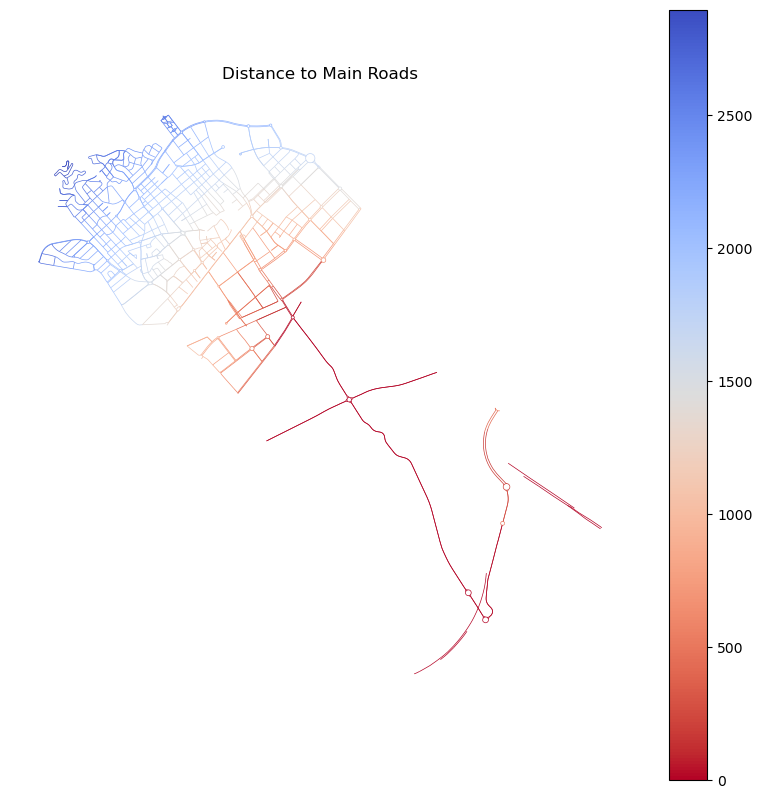

In [22]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

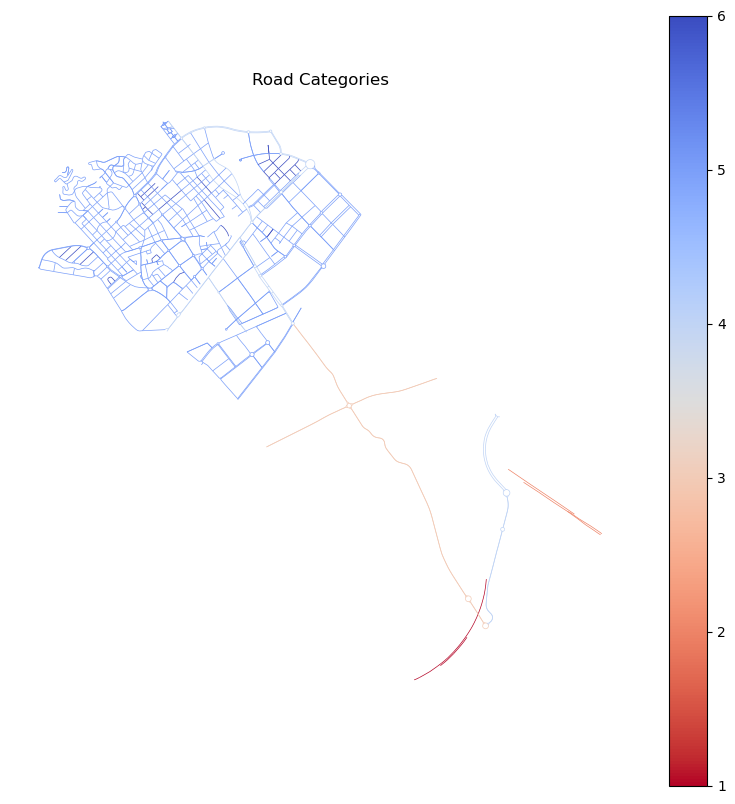

In [23]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [24]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,"[19803872, 674379918]",residential,NaN,NaN,"[Camí de la Via, Passatge de les Feixes Roca]",False,NaN,True,308.730134,"LINESTRING (417459.73 4573025.45, 417476.559 4...",...,residential,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769,49,908.189757
1,1186547995,trunk,3,100,Autovia de Castelldefels,True,C-31,False,228.543751,"LINESTRING (420311.04 4569795.488, 420365.614 ...",...,trunk,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962,1,0.000000
2,1188682904,trunk,2,100,Autovia de Castelldefels,True,C-31,False,188.820045,"LINESTRING (420171.05 4569668.905, 420184.271 ...",...,trunk,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827,1,0.000000
3,314132714,trunk,2,100,Autovia de Castelldefels,True,C-31,False,562.235744,"LINESTRING (420662.232 4570595.151, 420657.012...",...,trunk,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919,3,0.000000
4,"[23094061, 1392152182, 1392152183]",trunk,"[2, 3]",100,Autovia de Castelldefels,True,C-31,False,490.626414,"LINESTRING (420497.215 4570063.453, 420473.432...",...,trunk,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683,44,0.000000


## Export Viladecans noise streets layer

VIL_noise_streets.gpkg (layer `noise_streets`) in `deployment/Viladecans/layers/` — all
filtered street segments with segment_id, highway, name, length, dB values and noise
classes. This is the street layer consumed by the momepy / points / landuse notebooks.

In [25]:
export_cols = ['segment_id', 'highway', 'name', 'length',
               'db_day', 'db_evening', 'db_night',
               'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
export_gdf = noise_roads[[c for c in export_cols if c in noise_roads.columns]].copy()
export_gdf['name'] = export_gdf['name'].astype(str)
export_gdf['noise_day'] = export_gdf['noise_day'].astype(int)

out_gpkg = os.path.join(_layers_dir, 'VIL_noise_streets.gpkg')
export_gdf.to_file(out_gpkg, layer='noise_streets', driver='GPKG')
print('Exported:', out_gpkg)
print('Segments:', len(export_gdf))

Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Viladecans\layers\VIL_noise_streets.gpkg
Segments: 1613


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


## Create data frame

In [26]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'].astype(int),
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{f'dist_to_{c}': noise_roads[f'dist_to_{c}'] for c in road_categories},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,206378333_6315715548_0,3,3,3,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769
1,208568922_208568921_0,4,3,3,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962
2,208568926_208568922_1,4,3,3,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827
3,208595138_208595144_0,4,3,3,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919
4,208595144_2332249073_0,4,3,3,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683


## Check correlation with noise

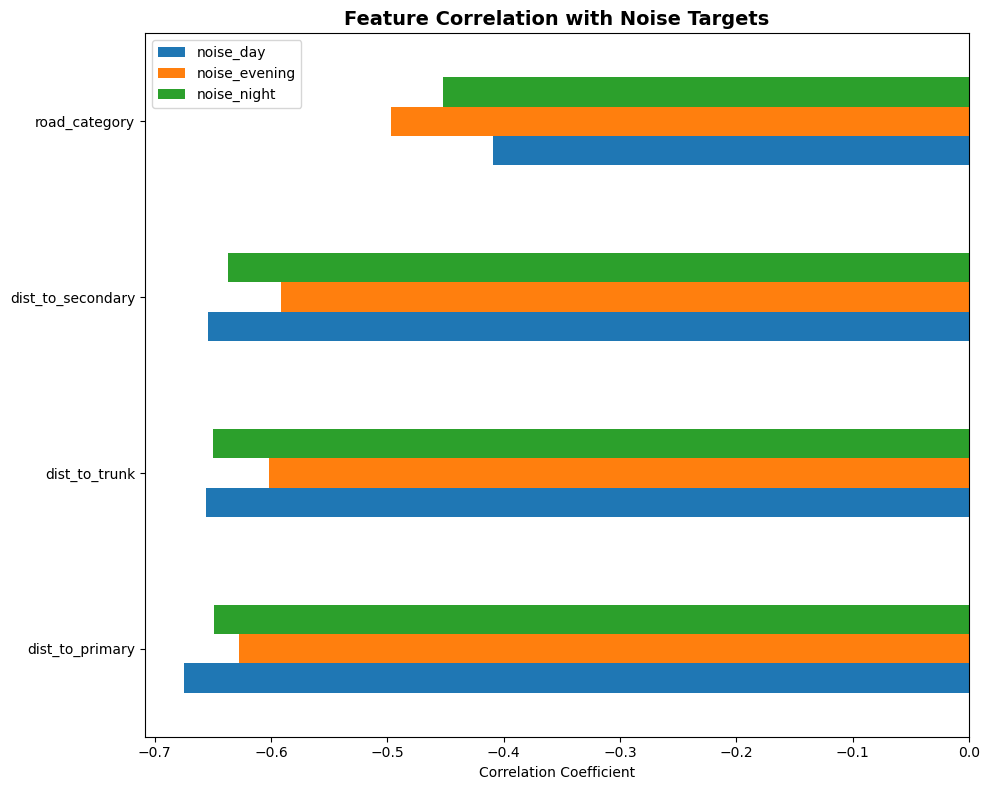

                   noise_day  noise_evening  noise_night
road_category      -0.408691      -0.496676    -0.451723
dist_to_secondary  -0.654089      -0.590989    -0.637283
dist_to_trunk      -0.655776      -0.602028    -0.649544
dist_to_primary    -0.674395      -0.627582    -0.649300


In [27]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night', 'road_category',
                            'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [28]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported osm_roads_noise_class.csv")

Exported osm_roads_noise_class.csv
